# fuzzy logic

we'll use: 
* initial_investment
* complexity_index
* risk_index
* market_growth_rate

In [31]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/raw_dataset.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (3265, 16)


,project_id,project_type,project_scale,project_duration_years,complexity_index,initial_investment,tax_rate,risk_index,year,inflation_rate,market_growth_rate,revenue,operating_cost,capex,working_capital,cash_flow
0,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,1,0.06,0.01,25091835.95,18278559.30,5887041.96,2220759.40,-2395752.07
1,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,2,0.07,0.04,31515722.37,21472504.85,2156997.60,2711995.95,5588259.78
2,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,3,0.09,0.08,47433995.67,36251329.00,4425897.72,4174260.40,3249734.67
3,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,4,0.05,0.06,48164969.53,35344119.92,1939175.23,4229398.99,8667076.68
4,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,5,0.06,0.12,67876067.92,49986826.23,4078154.71,5751746.19,9068670.71


In [3]:
features = [
    "initial_investment",
    "complexity_index",
    "risk_index",
    "market_growth_rate"
]

target = "cash_flow"

X = df[features]
y = df[target]

In [6]:
# taking only contiuous values for this: 
features = [
    "initial_investment",
    "complexity_index",
    "risk_index",
    "market_growth_rate"
]

target = "cash_flow"

X = df[features]
y = df[target]

In [32]:
from sklearn.model_selection import train_test_split

project_ids = df["project_id"].unique().to_numpy()

train_projects, test_projects = train_test_split(
    project_ids,
    test_size=0.20,
    random_state=42
)

train_df = df[
    df["project_id"].isin(train_projects)
].copy()

test_df = df[
    df["project_id"].isin(test_projects)
].copy()

print("Training projects:", train_df["project_id"].nunique())
print("Testing projects:", test_df["project_id"].nunique())

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training projects: 400
Testing projects: 100
Training rows: 2620
Testing rows: 645


In [8]:
X_train = train_df[features].copy()
y_train = train_df[target].copy()

X_test = test_df[features].copy()
y_test = test_df[target].copy()

In [9]:
from sklearn.preprocessing import MinMaxScaler

X_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(X_train)

X_test_scaled = X_scaler.transform(X_test)

In [10]:
y_scaler = MinMaxScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

gaussian membership functions

In [11]:
import numpy as np

def gaussian_membership(x, center, sigma):
    return np.exp(
        -0.5 * ((x - center) / sigma) ** 2
    )

In [12]:
def calculate_memberships(X):

    memberships = []

    centers = [0.0, 0.5, 1.0]
    sigma = 0.25

    for row in X:

        row_memberships = []

        for value in row:

            fuzzy_values = [
                gaussian_membership(
                    value,
                    center,
                    sigma
                )
                for center in centers
            ]

            row_memberships.append(
                fuzzy_values
            )

        memberships.append(row_memberships)

    return np.array(memberships)

In [13]:
train_memberships = calculate_memberships(
    X_train_scaled
)

test_memberships = calculate_memberships(
    X_test_scaled
)

print("Membership array shape:")
print(train_memberships.shape)

Membership array shape:
(2620, 4, 3)


fuzzy rules

In [14]:
from itertools import product

rules = list(
    product(
        range(3),
        repeat=len(features)
    )
)

print("Number of fuzzy rules:", len(rules))

Number of fuzzy rules: 81


In [15]:
def calculate_rule_strengths(memberships, rules):

    n_samples = memberships.shape[0]

    rule_strengths = np.zeros(
        (n_samples, len(rules))
    )

    for sample_idx in range(n_samples):

        for rule_idx, rule in enumerate(rules):

            strength = 1.0

            for feature_idx, fuzzy_set in enumerate(rule):

                strength *= memberships[
                    sample_idx,
                    feature_idx,
                    fuzzy_set
                ]

            rule_strengths[
                sample_idx,
                rule_idx
            ] = strength

    return rule_strengths

In [18]:
train_rule_strengths = calculate_rule_strengths(
    train_memberships,
    rules
)

test_rule_strengths = calculate_rule_strengths(
    test_memberships,
    rules
)

In [16]:
def normalize_rule_strengths(rule_strengths):

    row_sums = (
        rule_strengths.sum(
            axis=1,
            keepdims=True
        )
        + 1e-8
    )

    return rule_strengths / row_sums

In [19]:
train_normalized = normalize_rule_strengths(
    train_rule_strengths
)

test_normalized = normalize_rule_strengths(
    test_rule_strengths
)

In [20]:
def build_anfis_matrix(
    X_scaled,
    normalized_strengths
):

    n_samples = X_scaled.shape[0]
    n_rules = normalized_strengths.shape[1]

    matrix = np.zeros(
        (
            n_samples,
            n_rules * (X_scaled.shape[1] + 1)
        )
    )

    for sample_idx in range(n_samples):

        for rule_idx in range(n_rules):

            start = rule_idx * (
                X_scaled.shape[1] + 1
            )

            matrix[
                sample_idx,
                start:start + X_scaled.shape[1]
            ] = (
                normalized_strengths[
                    sample_idx,
                    rule_idx
                ]
                * X_scaled[sample_idx]
            )

            matrix[
                sample_idx,
                start + X_scaled.shape[1]
            ] = normalized_strengths[
                sample_idx,
                rule_idx
            ]

    return matrix

In [21]:
A_train = build_anfis_matrix(
    X_train_scaled,
    train_normalized
)

A_test = build_anfis_matrix(
    X_test_scaled,
    test_normalized
)

print("ANFIS training matrix:", A_train.shape)

ANFIS training matrix: (2620, 405)


In [23]:
from sklearn.linear_model import Ridge

anfis_model = Ridge(
    alpha=1.0
)

anfis_model.fit(
    A_train,
    y_train_scaled
)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [24]:
y_pred_scaled = anfis_model.predict(
    A_test
)

In [25]:
y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()

In [26]:
comparison = pd.DataFrame({
    "actual_cash_flow": y_test.values,
    "predicted_cash_flow": y_pred
})

comparison.head(10)

,actual_cash_flow,predicted_cash_flow
0,-2395752.07,6.467282e+06
1,5588259.78,6.189932e+06
2,3249734.67,6.538506e+06
3,8667076.68,6.273832e+06
4,9068670.71,7.271775e+06
5,10906457.69,6.387265e+06
6,7209321.18,6.189932e+06
7,10192767.52,6.206341e+06
8,10402911.22,6.538506e+06
9,1625496.13,3.983824e+06


In [34]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE:  ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  ₹6,218,473.56
RMSE: ₹9,109,124.76
R²:   0.1261


In [27]:
comparison = pd.DataFrame({
    "actual_cash_flow": y_test.values,
    "predicted_cash_flow": y_pred
})

comparison.head(10)

,actual_cash_flow,predicted_cash_flow
0,-2395752.07,6.467282e+06
1,5588259.78,6.189932e+06
2,3249734.67,6.538506e+06
3,8667076.68,6.273832e+06
4,9068670.71,7.271775e+06
5,10906457.69,6.387265e+06
6,7209321.18,6.189932e+06
7,10192767.52,6.206341e+06
8,10402911.22,6.538506e+06
9,1625496.13,3.983824e+06


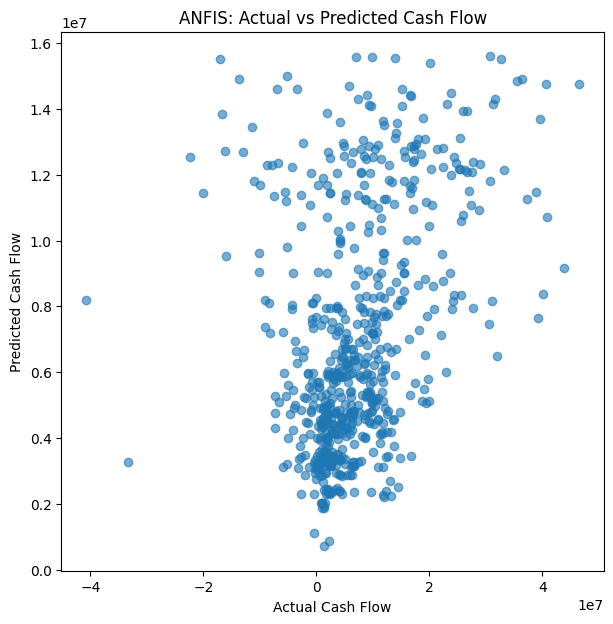

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Cash Flow")
plt.ylabel("Predicted Cash Flow")
plt.title("ANFIS: Actual vs Predicted Cash Flow")

plt.show()

In [35]:
results = {
    "model": "ANFIS",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

results

{'model': 'ANFIS',
 'MAE': 6218473.555552635,
 'RMSE': 9109124.763734821,
 'R2': 0.12614144686989592}